In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from sklearn.preprocessing import MinMaxScaler
from shapely.wkt import loads
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, Markdown

In [2]:
# 데이터 로드 및 CRS(좌표계) 통일

grid_gdf = gpd.read_file('./data/02._격자_(하남교산).geojson')
road_net = gpd.read_file('./data/08.상세도로망_네트워크.geojson')
future_risk = pd.read_csv('future_risk_index.csv')
facility_df = pd.read_csv('facility_lack_index.csv')
congest = pd.read_csv('congestion_index.csv')
cluster = pd.read_csv('cluster.csv')

# 데이터 병합 (GID 기준)
merged_df = future_risk.merge(facility_df[['gid', 'facility_lack_index']], on='gid', how='inner')
fri_gdf = grid_gdf.merge(merged_df[merged_df.columns.difference(['geometry'])], on='gid', how='inner')

# 클러스터링 페르소나 매칭

- 하이브리드 페르소나 매칭: 종합적 환경 정체성(현재위험도), 물리적 도로 특성(교차로 여부), 시설 설치의 근거(시설미비지수)를 결합하여 미래 위험도 격자(하남 신도시)의 군집화를 수행함.
- 각 군집별 시설물 매칭

In [3]:
# 도로 기하 구조 분석 (교차로 노드 추출)


# 3개 이상의 링크가 만나는 지점을 '교차로'로 정의
all_nodes = list(road_net['up_f_node']) + list(road_net['up_t_node'])
node_counts = pd.Series(all_nodes).value_counts()
intersection_node_ids = node_counts[node_counts >= 3].index

# 노드 ID를 포인트 좌표로 변환
road_net['start_pt'] = road_net.geometry.apply(lambda x: Point(x.coords[0]))
node_coords = road_net.set_index('up_f_node')['start_pt'].to_dict()

intersection_points = gpd.GeoDataFrame(
    geometry=[node_coords[node_id] for node_id in intersection_node_ids if node_id in node_coords],
    crs="EPSG:4326"
)


# 하이브리드 페르소나 매칭 (구조 + 지수 유사도)


# [A] 물리적 교차로 여부 판별 (Spatial Join)
sjoin_res = gpd.sjoin(fri_gdf, intersection_points, how='left', predicate='intersects')

fri_gdf['is_intersection'] = fri_gdf['gid'].isin(sjoin_res[sjoin_res.index_right.notna()]['gid'])


# [B] 클러스터 지수 평균값(Centroids) 정의
c0_center = {'current': 0.251, 'facility': 0.955} # 단일로형
c1_center = {'current': 0.333, 'facility': 0.822} # 교차로형


def final_persona_match(row):
    # 1. 지수 기반 거리 계산 (유사도)
    dist_to_c0 = abs(row['current_risk'] - c0_center['current']) + \
                 abs(row['facility_lack_index'] - c0_center['facility'])
    dist_to_c1 = abs(row['current_risk'] - c1_center['current']) + \
                 abs(row['facility_lack_index'] - c1_center['facility'])
    
    # 2. 최종 판정 논리:
    # 물리적 교차로가 있거나, 지수 특성이 교차로 군집(C1)에 더 가까우면 -> Cluster 1
    if row['is_intersection'] or (dist_to_c0 > dist_to_c1):
        return 1
    else:
        return 0

    
fri_gdf['final_cluster'] = fri_gdf.apply(final_persona_match, axis=1)


# 시설물 매칭


def suggest_facility(cluster):
    if cluster == 0:
        return "스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱)" # 시설미비/단일로형
    else:
        return "AI 감응형 스마트 횡단보도" # 교차로/신호위반형

fri_gdf['recommended_facility'] = fri_gdf['final_cluster'].apply(suggest_facility)


# 결과 저장
cluster_matching = fri_gdf.sort_values(by='FRI', ascending=False).copy()
cluster_matching.to_csv('cluster_matching.csv', index=False, encoding='utf-8-sig')

---

### 🏆 미래 위험 대응 및 시설 설치 우선순위 (Top 10)

,gid,FRI,current_risk,facility_lack_index,final_cluster,recommended_facility
29,다사749487,1.3264,0.6998,1.00,0,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱)
33,다사751480,1.2034,0.6891,0.93,0,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱)
22,다사743485,1.1732,0.7211,1.00,0,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱)
27,다사747485,1.1203,0.6203,0.91,1,AI 감응형 스마트 횡단보도
21,다사742474,1.0756,0.5378,0.98,0,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱)
32,다사750488,1.0540,0.5561,0.91,1,AI 감응형 스마트 횡단보도
40,다사757484,1.0306,0.5524,1.00,0,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱)
31,다사750480,1.0056,0.6181,0.98,1,AI 감응형 스마트 횡단보도
4,다사731470,1.0042,0.5851,1.00,0,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱)
20,다사738470,0.9659,0.5531,0.96,0,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱)


---


💡 분석 요약
1. **물리적 환경과 정체성의 결합** : 혼잡도·수요·사고 이력이 통합된 **'현재위험도(환경 정체성)'** 와 도로 기하 구조인 **'교차로 여부'** 를 페르소나 정의의 핵심 변수로 활용하여 분석의 입체성을 높였습니다.
2. **시설 설치의 정당성 확보** : 비록 가중치는 낮으나 최종 결론인 **시설물 설치를 정당화하기 위한 '대안의 근거'** 로서 **'시설미비지수'** 를 클러스터링 변수로 조합하여 분석의 논리적 완결성을 확보했습니다.
3. **선제적 안전 인프라 설계** : 교차로 위험군과 시설미비 단일로군으로 구분된 하이브리드 페르소나를 바탕으로, 고위험 구역 특성에 최적화된 '스마트 안전 시설 패키지' 가이드라인을 수립했습니다.
- **파일 이름**: `cluster_matching.csv`


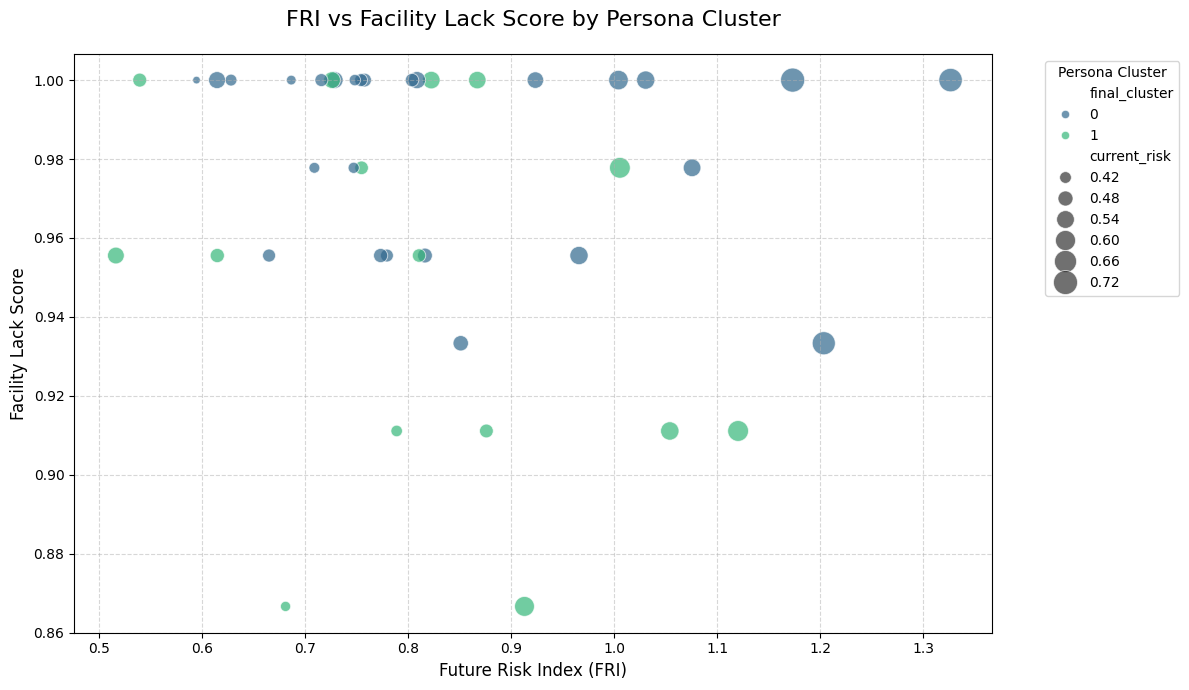

In [4]:
# 요약 및 시각화

display(Markdown("---"))
display(Markdown("### 🏆 미래 위험 대응 및 시설 설치 우선순위 (Top 10)"))
styled_table = (cluster_matching.head(10)
                [['gid', 'FRI', 'current_risk', 'facility_lack_index', 'final_cluster', 'recommended_facility']]
                .style.background_gradient(cmap='YlOrRd', subset=['FRI'])
                .format({'FRI': '{:.4f}', 'current_risk': '{:.4f}', 'facility_lack_index': '{:.2f}'})
                .set_properties(**{'text-align': 'center'}))
display(styled_table)

display(Markdown("---"))

display(Markdown(f"""
💡 분석 요약
1. **물리적 환경과 정체성의 결합** : 혼잡도·수요·사고 이력이 통합된 **'현재위험도(환경 정체성)'** 와 도로 기하 구조인 **'교차로 여부'** 를 페르소나 정의의 핵심 변수로 활용하여 분석의 입체성을 높였습니다.
2. **시설 설치의 정당성 확보** : 비록 가중치는 낮으나 최종 결론인 **시설물 설치를 정당화하기 위한 '대안의 근거'** 로서 **'시설미비지수'** 를 클러스터링 변수로 조합하여 분석의 논리적 완결성을 확보했습니다.
3. **선제적 안전 인프라 설계** : 교차로 위험군과 시설미비 단일로군으로 구분된 하이브리드 페르소나를 바탕으로, 고위험 구역 특성에 최적화된 '스마트 안전 시설 패키지' 가이드라인을 수립했습니다.
- **파일 이름**: `cluster_matching.csv`
"""))


# FRI 및 페르소나 분포 분석
plt.figure(figsize=(12, 7), facecolor='white')
sns.scatterplot(data=cluster_matching, x='FRI', y='facility_lack_index',
                hue='final_cluster', palette='viridis',
                size='current_risk', sizes=(30, 300), alpha=0.7)

plt.title('FRI vs Facility Lack Score by Persona Cluster', fontsize=16, pad=20)
plt.xlabel('Future Risk Index (FRI)', fontsize=12)
plt.ylabel('Facility Lack Score', fontsize=12)
plt.legend(title='Persona Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 스마트 안전 시설물 최적지 도출

 -  과거 사고 데이터와 격자별 혼잡도를 이식하여 시설 도입 시 예상되는 **안전 개선 편익($\Delta E$)** 과 **교통 소통 개선 편익($\Delta Flow$)** 을 시간 가치로 환산하여 최종 우선순위를 산정
 
 수식:
 $$E_i = \bar{S}_p \times W_{FRI,i} \quad , \quad T_i = \bar{C}_p \times W_{FRI,i}$$
$\bar{S}_p, \bar{C}_p$: 각 군집(페르소나)의 사고 심각도 및 혼잡도 평균값
 
$$\Delta E_i = (E_i \times R_{acc}) \times K_{time} \quad , \quad \Delta Flow_i = (T_i \times R_{flow}) \times K_{flow}$$

$$Final\ Priority\ Score_i = \alpha \cdot Z(\Delta E_i) + \beta \cdot Z(\Delta Flow_i)$$
$\alpha, \beta$ : 각 시설물별 사고 감소율

In [5]:
# 과거 사고 데이터와 혼잡 지수 병합
cluster_with_congest = pd.merge(cluster, congest, on='gid', how='left')

# 군집별 페르소나(심각도 및 혼잡도 평균) 산출
cluster_persona = cluster_with_congest.groupby('child_cluster').agg({
    'severity_score': 'mean',
    'mean_congestion_index': 'mean'
}).reset_index()

cluster_persona.rename(columns={
    'severity_score': 'P_Severity',
    'mean_congestion_index': 'P_Congest'
}, inplace=True)

# 하남 격자 데이터와 페르소나 병합
df_final = pd.merge(cluster_matching, cluster_persona, left_on='final_cluster', right_on='child_cluster', how='left')

# FRI 중복 계산 방지를 위한 군집 내 상대 가중치(W_i) 산출
cluster_avg_fri = df_final.groupby('final_cluster')['FRI'].transform('mean')
df_final['W_i'] = df_final['FRI'] / cluster_avg_fri

# 개별 잠재 지수 산출 (E_i: 잠재 사고량, T_i: 잠재 혼잡도)
df_final['E_i'] = df_final['P_Severity'] * df_final['W_i']
df_final['T_i'] = df_final['P_Congest'] * df_final['W_i']

In [6]:
#  계량적 개선 효과(Delta) 및 우선순위 점수 산출

# 상수 및 파라미터 설정
K = 15  # 시간 환산 계수 (EPDO 1점당 15분 정체 예방)
REDUCTION_MAP = {0: 0.8425, 1: 0.25} # 시설물별 사고 감소율 (0: 통합패키지, 1: 스마트횡단보도)

df_final['reduction_rate'] = df_final['final_cluster'].map(REDUCTION_MAP)

# 안전 편익 (delta_E) 및 소통 편익 (delta_Flow) 산출
df_final['delta_E'] = df_final['E_i'] * df_final['reduction_rate'] * K
df_final['delta_Flow'] = df_final['E_i'] * df_final['T_i'] * K

# 정규화 (Min-Max Scaling)
scaler = MinMaxScaler()
df_final[['s_E', 's_Flow']] = scaler.fit_transform(df_final[['delta_E', 'delta_Flow']])

# 최종 통합 점수 산출
df_final['final_priority_score'] = df_final['s_E'] + df_final['s_Flow']

display(Markdown("**✅ 편익 산출 완료:** 안전 및 소통 개선 효과의 시간 가치 환산 완료"))

**✅ 편익 산출 완료:** 안전 및 소통 개선 효과의 시간 가치 환산 완료

In [7]:
#  군집별 TOP 3 최종 후보지(총 6선) 선정

# 군집별 상위 3개 격자 추출
top_3_c0 = df_final[df_final['final_cluster'] == 0].sort_values('final_priority_score', ascending=False).head(3)
top_3_c1 = df_final[df_final['final_cluster'] == 1].sort_values('final_priority_score', ascending=False).head(3)
final_6 = pd.concat([top_3_c0, top_3_c1]).copy()

# 상세 선정 사유 자동 생성 함수
avg_fri = df_final['FRI'].mean()
avg_delta_e = df_final['delta_E'].mean()
avg_delta_flow = df_final['delta_Flow'].mean()

def generate_reason(row):
    fri_perf = row['FRI'] / avg_fri
    e_perf = row['delta_E'] / avg_delta_e
    flow_perf = row['delta_Flow'] / avg_delta_flow

    reason = (f"[위험도] FRI {row['FRI']:.2f}로 평균 대비 {fri_perf:.1f}배 높아 예방 시급. "
              f"[안전성] 시설 도입 시 연간 {row['delta_E']:.2f}분 가치의 사고 절감 기대(평균 대비 {e_perf:.1f}배). "
              f"[이동성] 사고 예방을 통해 연간 {row['delta_Flow']:.1f}분의 정체 파급 차단 효과(평균 대비 {flow_perf:.1f}배).")
    return reason

final_6['상세_선정사유'] = final_6.apply(generate_reason, axis=1)


# 좌표 변환
final_6['geometry'] = final_6['geometry'].to_wkt().apply(loads)
gdf_4326 = gpd.GeoDataFrame(final_6, geometry='geometry', crs="EPSG:4326")

gdf_5179 = gdf_4326.to_crs(epsg=5179)
gdf_5179['centroid_geom'] = gdf_5179.geometry.centroid
centroids_4326 = gdf_5179['centroid_geom'].to_crs(epsg=4326)
gdf_4326['lon'] = centroids_4326.x
gdf_4326['lat'] = centroids_4326.y

# 저장
gdf_4326.to_csv('final_6_locations.csv', index=False, encoding='utf-8-sig')

In [8]:
# 요약 및 시각화

# 분석 요약
display(Markdown("---"))
display(Markdown("### 🏆 하남 교산지구 스마트 안전 시설물 최종 최적지 (6선)"))
styled_report = (final_6[['gid', 'recommended_facility', 'FRI', 'delta_E', 'delta_Flow', 'final_priority_score','상세_선정사유']]
                 .style.background_gradient(cmap='YlGnBu', subset=['final_priority_score'])
                 .format({'FRI': '{:.4f}', 'delta_E': '{:.2f}', 'delta_Flow': '{:.1f}', 'final_priority_score': '{:.4f}'})
                 .set_properties(**{'text-align': 'center'}))
display(styled_report)


display(Markdown("---"))
display(Markdown(f"""
## 💡 분석 요약
1. **차원 통합적 우선순위** : 단순 사고 건수가 아닌 **미래 위험도(FRI)** 와 시설 결여도, 도로 구조를 모두 반영한 하이브리드 페르소나 기반의 최적지를 도출하였습니다.
2. **계량적 기대 효과 산출** : 시설물 도입을 통해 절감되는 사고 심각도와 정체 시간을 '분' 단위로 계량화하여, 설치 지점의 경제적 타당성을 입증하였습니다.
3. **군집별 맞춤형 솔루션** : 교차로 위험군(C1)에는 스마트 횡단보도를, 시설 미비 단일로 위험군(C0)에는 통합 패키지를 배치하여 신도시 안전망의 균형을 확보하였습니다.
- **파일 이름:** `hanam_final_6_locations.csv`
"""))

---

### 🏆 하남 교산지구 스마트 안전 시설물 최종 최적지 (6선)

,gid,recommended_facility,FRI,delta_E,delta_Flow,final_priority_score,상세_선정사유
0,다사749487,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱),1.3264,59.73,104.2,2.0000,[위험도] FRI 1.33로 평균 대비 1.6배 높아 예방 시급. [안전성] 시설 도입 시 연간 59.73분 가치의 사고 절감 기대(평균 대비 1.9배). [이동성] 사고 예방을 통해 연간 104.2분의 정체 파급 차단 효과(평균 대비 2.2배).
1,다사751480,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱),1.2034,54.19,85.7,1.6625,[위험도] FRI 1.20로 평균 대비 1.5배 높아 예방 시급. [안전성] 시설 도입 시 연간 54.19분 가치의 사고 절감 기대(평균 대비 1.8배). [이동성] 사고 예방을 통해 연간 85.7분의 정체 파급 차단 효과(평균 대비 1.8배).
2,다사743485,스마트 통합 패키지 (AI 감응형 스마트 횡단보도 + 감응형 스마트 방지턱),1.1732,52.83,81.5,1.5829,[위험도] FRI 1.17로 평균 대비 1.4배 높아 예방 시급. [안전성] 시설 도입 시 연간 52.83분 가치의 사고 절감 기대(평균 대비 1.7배). [이동성] 사고 예방을 통해 연간 81.5분의 정체 파급 차단 효과(평균 대비 1.7배).
3,다사747485,AI 감응형 스마트 횡단보도,1.1203,26.04,103.4,1.2847,[위험도] FRI 1.12로 평균 대비 1.4배 높아 예방 시급. [안전성] 시설 도입 시 연간 26.04분 가치의 사고 절감 기대(평균 대비 0.8배). [이동성] 사고 예방을 통해 연간 103.4분의 정체 파급 차단 효과(평균 대비 2.1배).
5,다사750488,AI 감응형 스마트 횡단보도,1.0540,24.50,91.5,1.1098,[위험도] FRI 1.05로 평균 대비 1.3배 높아 예방 시급. [안전성] 시설 도입 시 연간 24.50분 가치의 사고 절감 기대(평균 대비 0.8배). [이동성] 사고 예방을 통해 연간 91.5분의 정체 파급 차단 효과(평균 대비 1.9배).
7,다사750480,AI 감응형 스마트 횡단보도,1.0056,23.38,83.3,0.9875,[위험도] FRI 1.01로 평균 대비 1.2배 높아 예방 시급. [안전성] 시설 도입 시 연간 23.38분 가치의 사고 절감 기대(평균 대비 0.8배). [이동성] 사고 예방을 통해 연간 83.3분의 정체 파급 차단 효과(평균 대비 1.7배).


---


## 💡 분석 요약
1. **차원 통합적 우선순위** : 단순 사고 건수가 아닌 **미래 위험도(FRI)** 와 시설 결여도, 도로 구조를 모두 반영한 하이브리드 페르소나 기반의 최적지를 도출하였습니다.
2. **계량적 기대 효과 산출** : 시설물 도입을 통해 절감되는 사고 심각도와 정체 시간을 '분' 단위로 계량화하여, 설치 지점의 경제적 타당성을 입증하였습니다.
3. **군집별 맞춤형 솔루션** : 교차로 위험군(C1)에는 스마트 횡단보도를, 시설 미비 단일로 위험군(C0)에는 통합 패키지를 배치하여 신도시 안전망의 균형을 확보하였습니다.
- **파일 이름:** `hanam_final_6_locations.csv`
